<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY-14-AdaBoost_Classifier_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Model 1 — Basic AdaBoost
Objective

Generate dataset → Plot → Train → Predict → Evaluate

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split

In [5]:
x,y = make_classification(n_samples=300,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          class_sep=1.2,
                          random_state=42)

In [7]:
x.shape

(300, 2)

In [8]:
y.shape

(300,)

In [10]:
# data frame
import pandas as pd

df = pd.DataFrame(x, columns=["Feature_1", "Feature_2"])
df["Target"] = y

df.head()

,Feature_1,Feature_2,Target
0,0.933246,-1.631007,0
1,0.856043,1.042841,1
2,0.737983,-2.256550,0
3,1.489308,0.120977,1
4,0.920124,1.177237,1


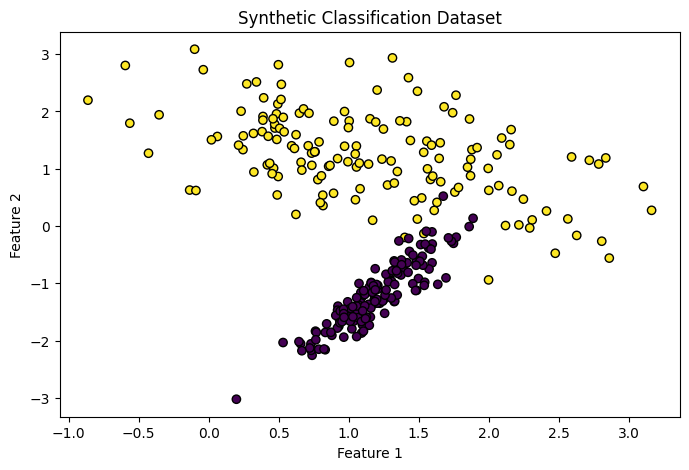

In [17]:
# plotting / visulatization
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Feature_1"],
    df["Feature_2"],
    c=df["Target"],
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Classification Dataset")
plt.show()

In [11]:
# train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size=0.2,
                                                 random_state=42,
                                                 stratify=y)

In [12]:
# making base model
from sklearn.tree import DecisionTreeClassifier
base_model  = DecisionTreeClassifier(max_depth=1,
                                     random_state=42)

In [14]:
# final ada boost model
abc= AdaBoostClassifier(estimator= base_model,
                        n_estimators=50,
                        learning_rate=1.0,
                        random_state=42)

In [15]:
# train the model
abc.fit(x_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

In [16]:
# making predictions
y_pred= abc.predict(x_test)

In [23]:
# calculating accuracy scores
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [24]:
# Classification Report:
# Precision
# Recall
# F1-score
# Supportprint
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



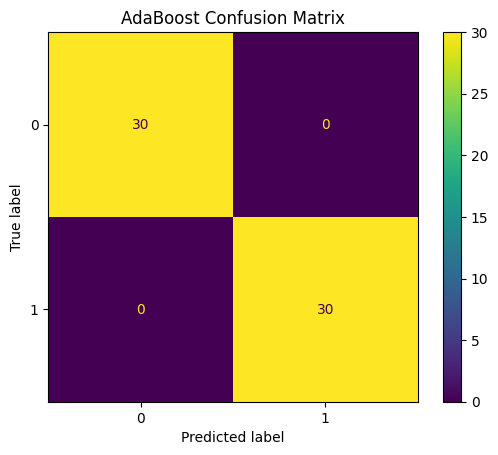

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("AdaBoost Confusion Matrix")
plt.show()

# 🧪 Model 2 — AdaBoost + Cross-Validation
Objective

Generate dataset → Plot → Train → Use Cross-Validation → Better performance estimation

First, an important distinction ⚠️

Cross-validation does not automatically make the model's predictions better.

It primarily helps us:

1. Estimate generalization performance more reliably.
2. Detect whether performance depends heavily on one train-test split.
3. Compare models.
4. Select hyperparameters when combined with tuning.

In [26]:
# making data sets
x,y = make_classification(n_samples=500,
                          n_features=2,
                          n_informative=2,
                          n_redundant =0,
                          n_clusters_per_class=1,
                          class_sep=1.0,
                          random_state=42)

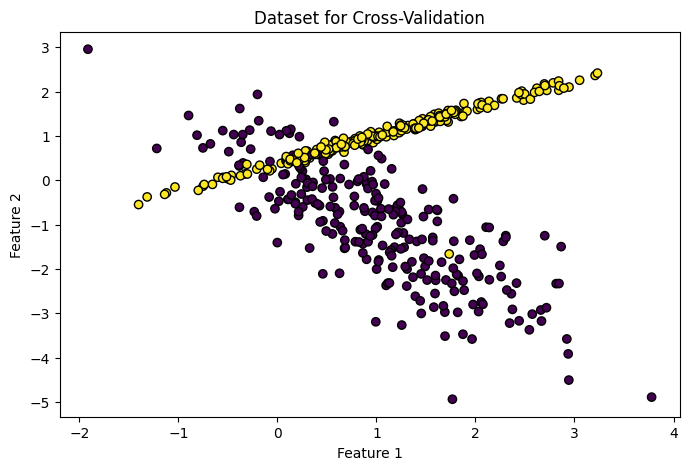

In [30]:
# plotting dataset /visualization
plt.figure(figsize=(8, 5))

plt.scatter(
    x[:, 0],
    x[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset for Cross-Validation")
plt.show()

In [34]:
# Create Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

base_model = DecisionTreeClassifier(max_depth = 1,
                                    random_state=42)

abc = AdaBoostClassifier(estimator = base_model,
                         n_estimators= 50,
                         learning_rate=1.0,
                         random_state= 42)

In [36]:
# tuning cv / Define Stratified K-Fold
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits = 5,
                     shuffle = True,
                     random_state=42
                     )

What happens here?

The dataset is divided into 5 folds.

* Fold 1 → Test | Fold 2 + 3 + 4 + 5 → Train
* Fold 2 → Test | Fold 1 + 3 + 4 + 5 → Train
* Fold 3 → Test | Fold 1 + 2 + 4 + 5 → Train
* Fold 4 → Test | Fold 1 + 2 + 3 + 5 → Train
* Fold 5 → Test | Fold 1 + 2 + 3 + 4 → Train

Each fold gets one chance to act as validation data.

In [38]:
# Apply Cross-Validation
cv_scores = cross_val_score(abc,
                            x,
                            y,
                            cv=cv,
                            scoring= "accuracy")
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

CV Scores: [0.8  0.87 0.89 0.84 0.88]
Mean CV Accuracy: 0.8560000000000001
Standard Deviation: 0.03261901286060017


These are illustrative values.

Interpretation
* Mean CV Accuracy: Average performance across folds.
* Standard Deviation: Variation across folds.
* Lower standard deviation often indicates more consistent performance, but it is not the only factor.

In [39]:
# Train Final Model

#After evaluating with CV, train the model on the complete dataset if your goal is a final model for deployment.

abc.fit(x, y)

# Important

# Cross-validation itself does not permanently train one final model for deployment. It evaluates repeated fitted models. You generally fit a final model afterward.

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

# 🧪Model 3 — AdaBoost + GridSearchCV
Objective

Generate dataset → Plot → Train → Tune hyperparameters → Select best model → Predict

This is where AdaBoost becomes more interview- and project-ready.

What is GridSearchCV?

* GridSearchCV tests multiple combinations of hyperparameters using cross-validation and selects the combination that performs best according to a chosen scoring metric.

In [40]:
from sklearn.model_selection import GridSearchCV

In [57]:
#  generate data set
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.0,
    random_state=42
)

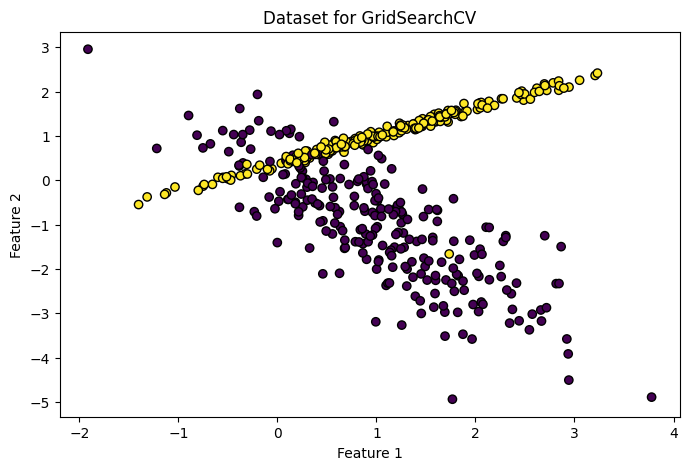

In [58]:
# Plot Dataset
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset for GridSearchCV")
plt.show()

In [59]:
# making base model
from sklearn.tree import DecisionTreeClassifier

base_model = DecisionTreeClassifier(random_state=42)

In [60]:
# making ada boost classifier
from sklearn.ensemble import AdaBoostClassifier

abc=AdaBoostClassifier(estimator=base_model,
                       random_state=42)

In [61]:
# defining parameters
param_grid = { "n_estimators" : [25,50,100],
               "learning_rate": [0.01, 0.1, 1.0],
               "estimator__max_depth": [1, 2, 3]
}

In [62]:
# create grid search cv
grid_cv = GridSearchCV(estimator=abc,
                       param_grid = param_grid,
                       cv=5,
                       n_jobs=-1,
                       scoring="accuracy",
                       )

What happens?

If there are:

3 values of n_estimators
3 values of learning_rate
3 values of max_depth

Total combinations:

$$ 3 \times 3 \times 3 = 27 $$

With 5-fold CV:

$$ 27 \times 5 = 135 $$

So GridSearchCV evaluates 135 model fits, excluding any final refit.

In [63]:
# training grid search cv
grid_cv.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [1, 2, 3],
                         'learning_rate': [0.01, 0.1, 1.0],
                         'n_estimators': [25, 50, 100]},
             scoring='accuracy')

In [64]:
# finding best parameter
print("Best Parameters:")
print(grid_cv.best_params_)

Best Parameters:
{'estimator__max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 50}


In [65]:
# Best CV Score
print("Best CV Accuracy:", grid_cv.best_score_)

Best CV Accuracy: 0.9708333333333334


In [66]:
# Best Model
best_model = grid_cv.best_estimator_

In [67]:
# prediction
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

grid_cv.fit(x_train,y_train)

best_model = grid_cv.best_estimator_

y_pred = best_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.95


# 🧪 Model 4 — AdaBoost + Feature Importance + Decision Boundary

This is the extra step I strongly recommend adding. It helps you understand what the model learned, not just its accuracy.

In [68]:
importance = best_model.feature_importances_

print("Feature Importances:", importance)

Feature Importances: [0.37418472 0.62581528]


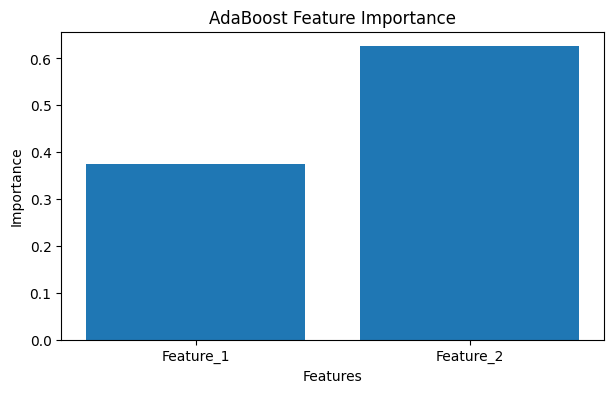

In [69]:
features = ["Feature_1", "Feature_2"]

plt.figure(figsize=(7, 4))

plt.bar(features, importance)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("AdaBoost Feature Importance")
plt.show()

<Figure size 800x500 with 0 Axes>

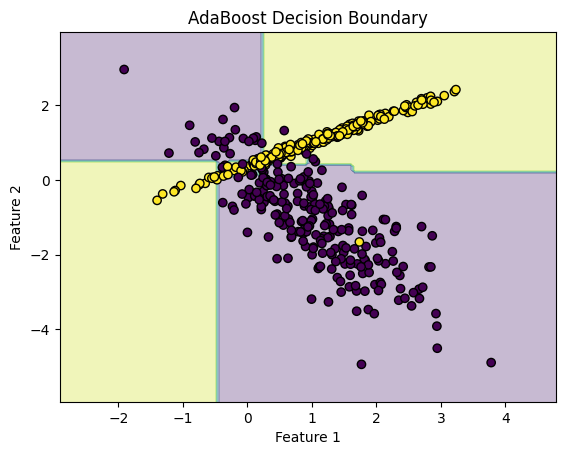

In [70]:
from sklearn.inspection import DecisionBoundaryDisplay

plt.figure(figsize=(8, 5))

DecisionBoundaryDisplay.from_estimator(
    best_model,
    X,
    response_method="predict",
    alpha=0.3
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("AdaBoost Decision Boundary")
plt.show()

# 🧪 Model 5 — Compare AdaBoost with a Single Decision Tree

This is a very valuable experiment.

Objective

Prove whether combining weak learners improves performance compared with one weak learner.

In [73]:
single_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

single_tree.fit(x_train, y_train)

tree_pred = single_tree.predict(x_test)

print(
    "Single Stump Accuracy:",
    accuracy_score(y_test, tree_pred)
)

print(
    "AdaBoost Accuracy:",
    accuracy_score(y_test, y_pred)
)

Single Stump Accuracy: 0.9
AdaBoost Accuracy: 0.95
